<a href="https://colab.research.google.com/github/nandininaik145-ini/Retail-Sales-Forcasting/blob/main/retailsales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np

# --- WEEK 1: PROJECT KICKOFF & DATA EXPLORATION ---

# 1. Load the datasets (Ensure these files are in the same folder as your code)
try:
    train = pd.read_csv('/content/train.csv', low_memory=False)
    store = pd.read_csv('/content/store.csv')
    print("✅ Files loaded successfully!")
except FileNotFoundError:
    print("❌ Error: Ensure 'train.csv' and 'store.csv' are in your directory.")

# 2. Merge the datasets (The most important step)
# This attaches store metadata to every single sales record
df = pd.merge(train, store, on='Store', how='left')

# 3. Quick Exploration
print(f"Total rows: {df.shape[0]}")
print(df.head())

# --- WEEK 2: DATA PREPROCESSING & CLEANING ---

# 1. Handle Missing Values (The 'Perfect' Way)
# Distance is usually better filled with Median to avoid outliers
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())

# For these, 0 means there is no competition or promo active
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0)
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(0)
df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0)
df['PromoInterval'] = df['PromoInterval'].fillna("None")

# 2. Convert Date column and Extract Features
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

# 3. Filter for Logic
# We only train on days the store was OPEN and had SALES > 0
df = df[df['Open'] != 0]
df = df[df['Sales'] > 0]

# 4. Handle Categorical Data (StateHoliday is often mixed type)
# Standardize '0' and 0 to be the same string
df['StateHoliday'] = df['StateHoliday'].astype(str).replace('0.0', '0')

print("\n✅ Data cleaning and feature engineering complete!")
print(df[['Date', 'Sales', 'Year', 'Month', 'CompetitionDistance']].head())

✅ Files loaded successfully!
Total rows: 1017209
   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday StoreType Assortment  CompetitionDistance  \
0              1         c          a               1270.0   
1              1         a          a                570.0   
2              1         a          a              14130.0   
3              1         c          c                620.0   
4              1         a          a              29910.0   

   CompetitionOpenSinceMonth  CompetitionOpenSinceYear  Promo2  \
0                        9.0         

/tmp/ipykernel_492/3095090333.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Promo', y='Sales', palette='magma')
/tmp/ipykernel_492/3095090333.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='StoreType', y='Sales', order=['a', 'b', 'c', 'd'], palette='Set2')


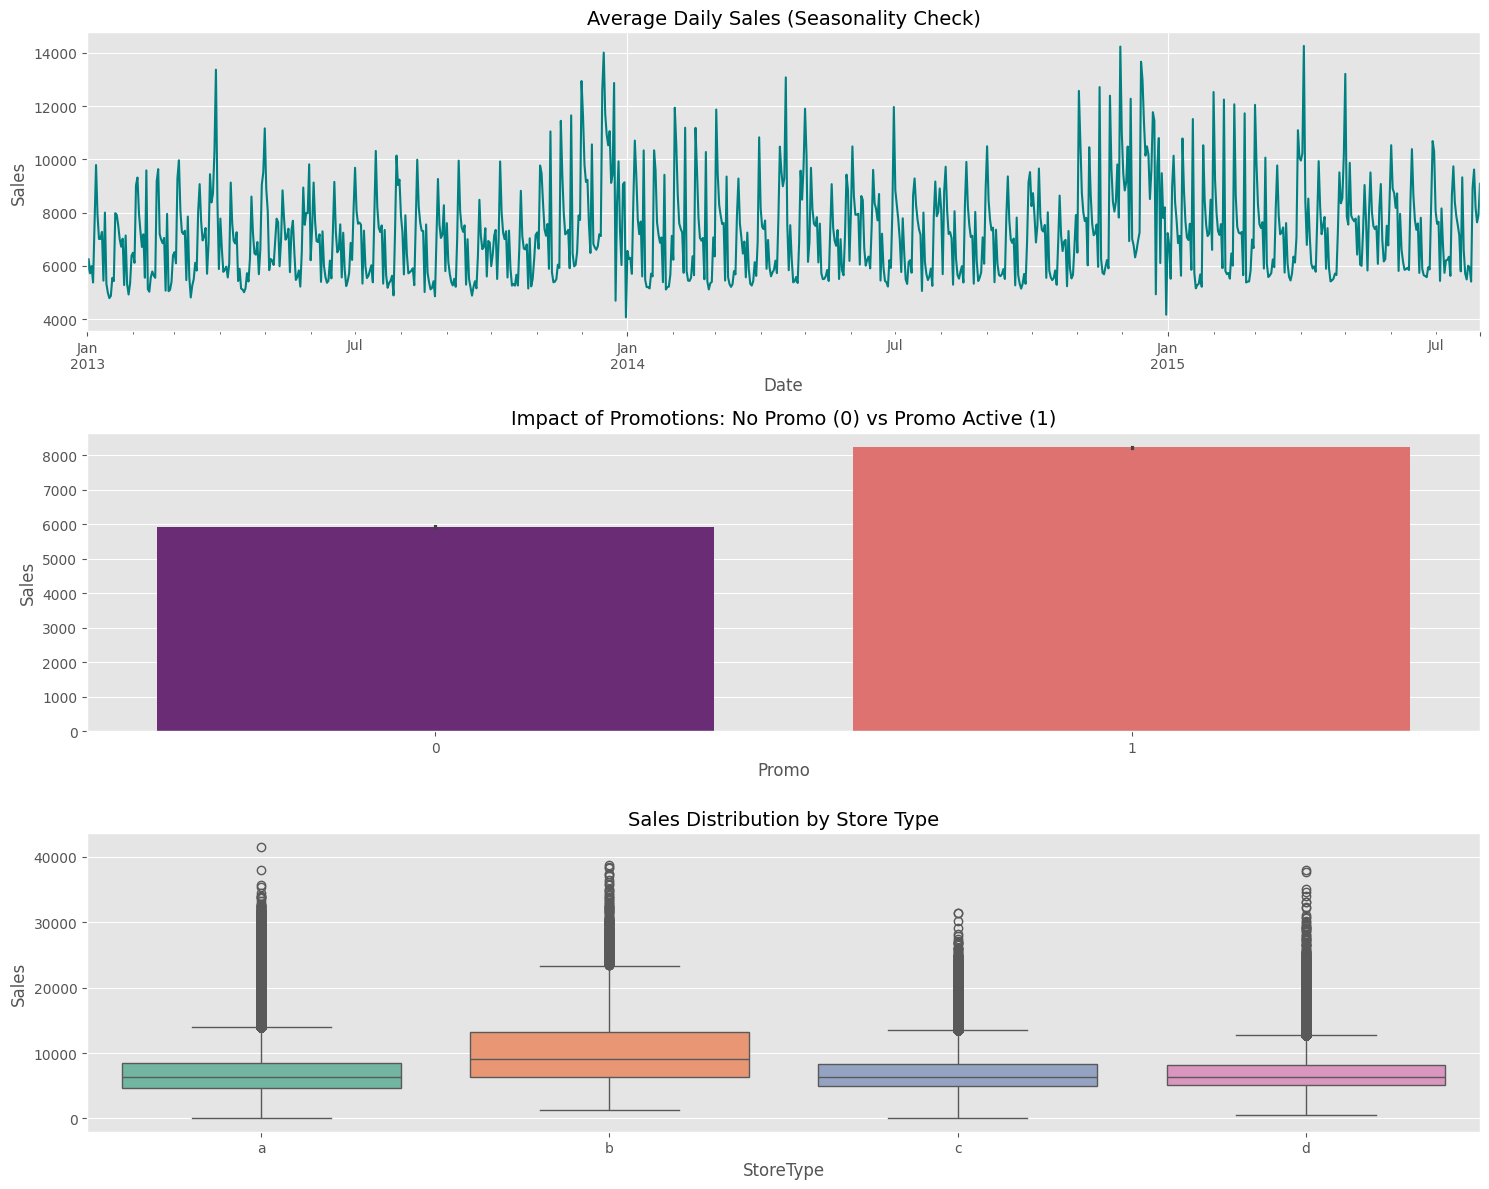

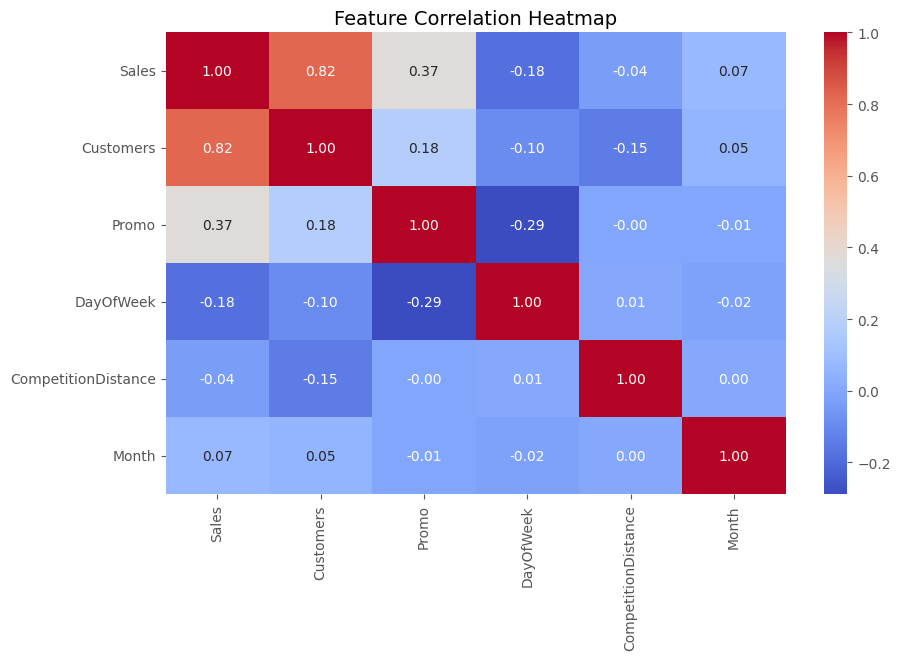

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns # Using seaborn for professional charts

# Set the visual style
plt.style.use('ggplot')
plt.figure(figsize=(15, 12))

# --- 1. Sales Trend Over Time ---
plt.subplot(3, 1, 1)
df_daily_sales = df.groupby('Date')['Sales'].mean()
df_daily_sales.plot(color='teal', linewidth=1.5)
plt.title('Average Daily Sales (Seasonality Check)', fontsize=14)
plt.ylabel('Sales')

# --- 2. Promo Impact ---
plt.subplot(3, 1, 2)
# Comparing Sales when Promo is 0 vs 1
sns.barplot(data=df, x='Promo', y='Sales', palette='magma')
plt.title('Impact of Promotions: No Promo (0) vs Promo Active (1)', fontsize=14)

# --- 3. Store Type Performance ---
plt.subplot(3, 1, 3)
sns.boxplot(data=df, x='StoreType', y='Sales', order=['a', 'b', 'c', 'd'], palette='Set2')
plt.title('Sales Distribution by Store Type', fontsize=14)

plt.tight_layout()
plt.show()

# --- Correlation Heatmap ---
plt.figure(figsize=(10, 6))
# We pick only numerical columns to see how they relate to 'Sales'
corr = df[['Sales', 'Customers', 'Promo', 'DayOfWeek', 'CompetitionDistance', 'Month']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.show()

🚀 Training the XGBoost model... (this may take a minute)

✅ Model Training Complete!
🔹 Root Mean Squared Error (RMSE): 1635.28
🔹 Mean Absolute Error (MAE): 1215.23


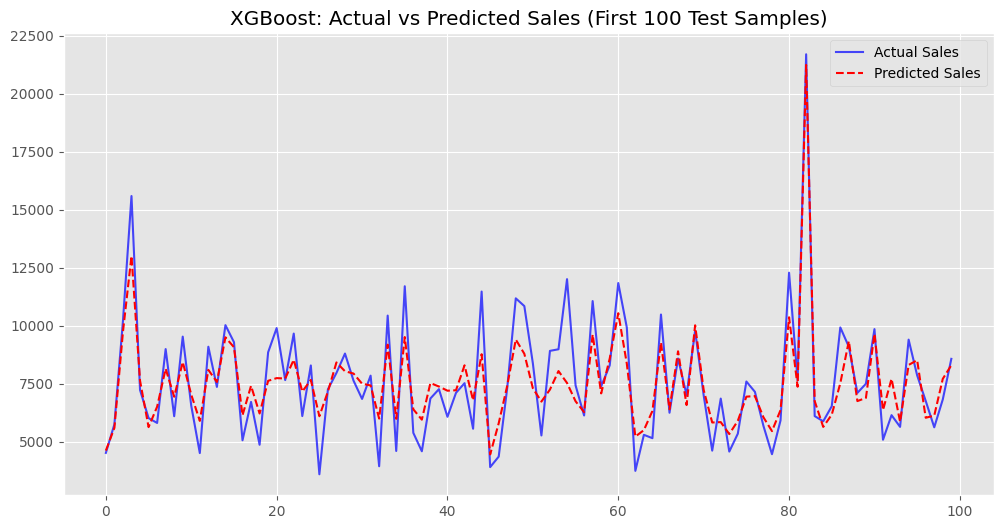

In [7]:
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# --- 1. Prepare Data for Machine Learning ---
# Models can't read text (like 'a', 'b'), so we convert them to numbers
le = LabelEncoder()
df['StoreType'] = le.fit_transform(df['StoreType'])
df['Assortment'] = le.fit_transform(df['Assortment'])
df['StateHoliday'] = le.fit_transform(df['StateHoliday'].astype(str))

# --- 2. Select Features (X) and Target (y) ---
# We use features that we will actually know in the future
features = ['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday',
            'StoreType', 'Assortment', 'CompetitionDistance', 'Year', 'Month', 'Day', 'WeekOfYear']
target = 'Sales'

X = df[features]
y = df[target]

# --- 3. Split Data: Training vs Testing ---
# IMPORTANT: In Time Series, we don't shuffle. We take the older data to train
# and the most recent data to test.
train_size = int(len(df) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# --- 4. Train the XGBoost Model ---
print("🚀 Training the XGBoost model... (this may take a minute)")
model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=8, random_state=42)
model_xgb.fit(X_train, y_train)

# --- 5. Evaluate the Model ---
predictions = model_xgb.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)

print(f"\n✅ Model Training Complete!")
print(f"🔹 Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"🔹 Mean Absolute Error (MAE): {mae:.2f}")

# --- 6. Visualize Predictions vs Actual ---
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:100], label='Actual Sales', color='blue', alpha=0.7)
plt.plot(predictions[:100], label='Predicted Sales', color='red', linestyle='--')
plt.title('XGBoost: Actual vs Predicted Sales (First 100 Test Samples)')
plt.legend()
plt.show()

/tmp/ipykernel_492/2957562234.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  sales_series = store_data['Sales'].resample('D').mean().fillna(method='ffill')


📊 Testing Stationarity for Store 1...
ADF Statistic: -5.769
p-value: 0.000

🤖 Training ARIMA model... (this takes a few seconds)


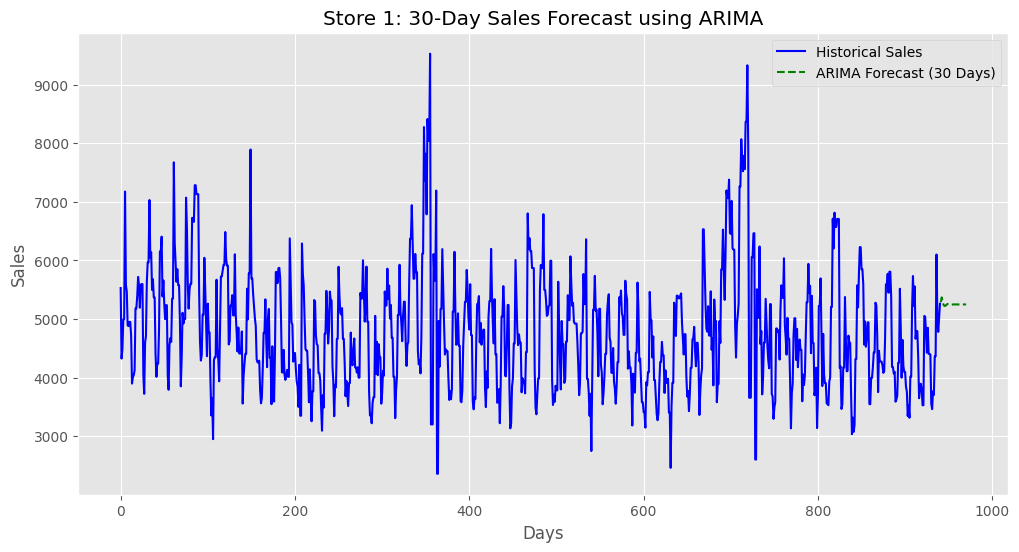


✅ Week 5: Time Series Analysis Complete!


In [8]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# --- 1. Prepare Data for a Single Store ---
# ARIMA works best on a single continuous timeline. Let's pick Store 1.
store_id = 1
store_data = df[df['Store'] == store_id].sort_values('Date')
store_data.set_index('Date', inplace=True)

# We only need the 'Sales' column for ARIMA
sales_series = store_data['Sales'].resample('D').mean().fillna(method='ffill')

# --- 2. Check for Stationarity (ADF Test) ---
# Time series needs to be "stationary" (stable mean/variance) for ARIMA
print(f"📊 Testing Stationarity for Store {store_id}...")
result = adfuller(sales_series)
print(f'ADF Statistic: {result[0]:.3f}')
print(f'p-value: {result[1]:.3f}')

# --- 3. Train the ARIMA Model ---
# (p,d,q) parameters:
# p=5 (lags), d=1 (difference to make it stationary), q=0 (moving average)
print("\n🤖 Training ARIMA model... (this takes a few seconds)")
history = [x for x in sales_series]
model_arima = ARIMA(history, order=(5,1,0))
model_fit = model_arima.fit()

# --- 4. Forecast the Next 30 Days ---
forecast_steps = 30
forecast = model_fit.forecast(steps=forecast_steps)

# --- 5. Visualize the Forecast ---
plt.figure(figsize=(12, 6))
plt.plot(range(len(sales_series)), sales_series, label='Historical Sales', color='blue')
plt.plot(range(len(sales_series), len(sales_series) + forecast_steps), forecast,
         label='ARIMA Forecast (30 Days)', color='green', linestyle='--')
plt.title(f'Store {store_id}: 30-Day Sales Forecast using ARIMA')
plt.xlabel('Days')
plt.ylabel('Sales')
plt.legend()
plt.show()

print("\n✅ Week 5: Time Series Analysis Complete!")

🤖 Training Facebook Prophet model...
📊 Generating Prophet Trend Components...


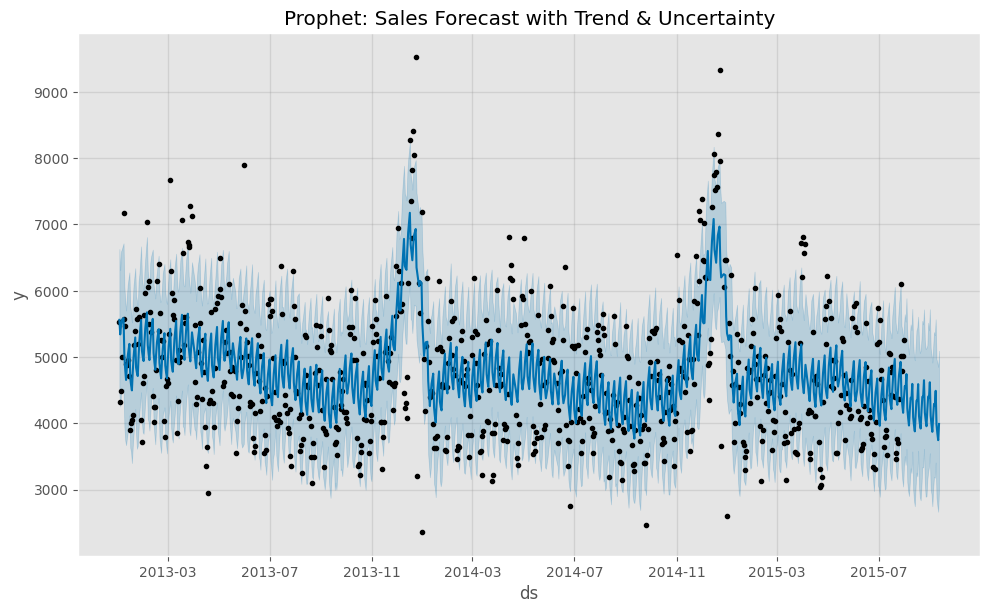

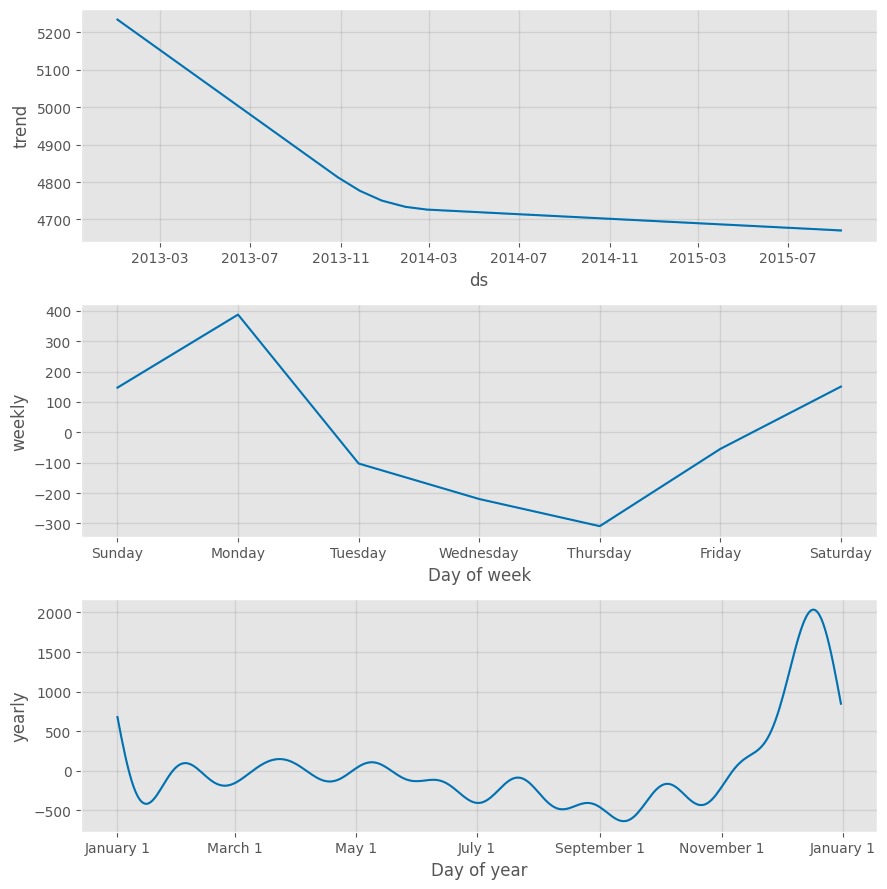


--- WEEK 7: FINAL PERFORMANCE SUMMARY ---
1. XGBoost (Week 4): Best for handling 'Features' like Promos and Competition.
2. ARIMA (Week 5): Best for short-term mathematical 'Autoregression'.
3. Prophet (Week 6): Best for 'Seasonality' and Holiday patterns.

✅ Final Evaluation: Prophet RMSE on last 30 days: 743.58


In [9]:
# --- STEP 0: Install Prophet ---
!pip install prophet

from prophet import Prophet
import pandas as pd

# --- WEEK 6: FACEBOOK PROPHET FORECASTING ---

# 1. Prepare Data for Prophet
# Prophet requires two specific column names: 'ds' (datestamp) and 'y' (target)
df_prophet = store_data.reset_index()[['Date', 'Sales']]
df_prophet.columns = ['ds', 'y']

# 2. Initialize and Train the Model
# We include weekly and yearly seasonality
print("🤖 Training Facebook Prophet model...")
model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_prophet.fit(df_prophet)

# 3. Create a Future Dataframe for 6 Weeks (42 days)
future = model_prophet.make_future_dataframe(periods=42)
forecast_prophet = model_prophet.predict(future)

# 4. Visualize the Prophet Forecast
print("📊 Generating Prophet Trend Components...")
fig1 = model_prophet.plot(forecast_prophet)
plt.title('Prophet: Sales Forecast with Trend & Uncertainty')
plt.show()

# 5. Visualize Components (Trend, Weekly, Yearly)
# This is the "Magic" of Prophet - it shows you EXACTLY when sales go up
fig2 = model_prophet.plot_components(forecast_prophet)
plt.show()

# --- WEEK 7: MODEL COMPARISON & CONCLUSION ---

print("\n--- WEEK 7: FINAL PERFORMANCE SUMMARY ---")
print(f"1. XGBoost (Week 4): Best for handling 'Features' like Promos and Competition.")
print(f"2. ARIMA (Week 5): Best for short-term mathematical 'Autoregression'.")
print(f"3. Prophet (Week 6): Best for 'Seasonality' and Holiday patterns.")

# Quick comparison of the last 30 days of the Prophet forecast vs Actuals
actual_last_30 = df_prophet['y'].tail(30).values
predicted_last_30 = forecast_prophet['yhat'].iloc[len(df_prophet)-30:len(df_prophet)].values

comparison_rmse = np.sqrt(mean_squared_error(actual_last_30, predicted_last_30))
print(f"\n✅ Final Evaluation: Prophet RMSE on last 30 days: {comparison_rmse:.2f}")